## TEMPO — Initialization

**TEMPO** discovers $M$ latent regimes in snapshot data via Expectation-Maximization,
training a dedicated POD basis for each regime.

Initialization (3 steps):
1. **Global POD** — SVD on all snapshots $\{s^{(i)}\}_{i=1}^N$ → coefficients $\alpha^{(i)} \in \mathbb{R}^P$
2. **GMM** — fit Gaussian mixture on $\{\alpha^{(i)}\}$ → soft assignments $\gamma \in \mathbb{R}^{N \times M}$
3. **Regime bases** — train $M$ weighted POD bases: $\min_{\Phi_m} \sum_i \gamma_{im} \|s^{(i)} - \hat{s}_m^{(i)}\|^2$


In [1]:
import numpy as np
import torch
import sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
sys.path.insert(0, str(pathlib.Path("..").resolve()))

from models.tempo import TEMPOTrainer, TEMPOConfig, pod_factory, fourier_pod_factory
from models.pod import PODConfig
from models.fourier_neural_pod import FourierNeuralPODConfig
from utils.datasets import load, download

if torch.backends.mps.is_available():
    DEVICE = 'mps'
elif torch.cuda.is_available():
    DEVICE = 'cuda'
else:
    DEVICE = 'cpu'
DEVICE


def draw_cov_ellipse(ax, mean2d, cov2d, color, n_std=2.0, **kwargs):
    """Draw covariance ellipse from 2x2 covariance matrix"""
    vals, vecs = np.linalg.eigh(cov2d)
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    w, h  = 2 * n_std * np.sqrt(np.abs(vals))
    ellipse = Ellipse(mean2d, w, h, angle=angle,
                      edgecolor=color, facecolor="none", lw=2, **kwargs)
    ax.add_patch(ellipse)

### Data

Parameters:

In [2]:
nu_values = [0.001, 0.01, 0.1, 1.0]
N_samples  = 5500

In [3]:
tensors, kappas, ts = [], [], []

Loading:

In [4]:
for nu in nu_values:
    data = load(f"Burgers_Nu{nu}")
    u = data["tensor"][:N_samples, :, :, 0]   # (N_samples, Nt, Nx)
    t_np = data["t-coordinate"]                # (Nt,)
    x_np = data["x-coordinate"]               # (Nx,)

    N, Nt, Nx = u.shape
    u_flat = u.reshape(-1, Nx)                 # (N*Nt, Nx)
    t_flat = np.tile(t_np, N)                  # (N*Nt,)
    k_flat = np.full(len(t_flat), nu)          # (N*Nt,)

    tensors.append(u_flat)
    kappas.append(k_flat)
    ts.append(t_flat)

In [5]:
s_np     = np.concatenate(tensors, axis=0)    # (N_total, Nx)
t_np_all = np.concatenate(ts,      axis=0)    # (N_total,)
k_np_all = np.concatenate(kappas,  axis=0)    # (N_total,)

s     = torch.tensor(s_np,                dtype=torch.float32, device=DEVICE)
t     = torch.tensor(t_np_all,            dtype=torch.float32, device=DEVICE)
x     = torch.tensor(x_np[:, None],       dtype=torch.float32, device=DEVICE)
kappa = torch.tensor(k_np_all[:, None],   dtype=torch.float32, device=DEVICE)
gamma = torch.ones(len(s), dtype=torch.float32, device=DEVICE) / len(s)


In [6]:
print(f"s={s.shape}, t={t.shape}, x={x.shape}, kappa={kappa.shape}")

s=torch.Size([5632000, 101]), t=torch.Size([5632000]), x=torch.Size([101, 1]), kappa=torch.Size([5632000, 1])


# **TEMPO:**

### **POD**

In [7]:
cfg = TEMPOConfig(
    M=3,
    basis_config=PODConfig(max_modes=1),
    basis_factory=pod_factory,
    P_global = 3
)

regime_colors = np.array([
    [0.27, 0.51, 0.71, 1.0],
    [0.84, 0.37, 0.30, 1.0],
    [0.30, 0.64, 0.42, 1.0],
    [0.75, 0.55, 0.24, 1.0],
])[:cfg.M]

In [8]:
trainer = TEMPOTrainer(cfg)
trainer._initialize(s, x, t, kappa)

POD | N=5632000, Ny=101 | max_modes=3, tol=1.0
  P=3 modes (100.00% variance threshold, needed 101)
  mode  1: sigma=6.0450e+00  cumvar=92.59%  res_mse=2.8989e-02
  mode  2: sigma=1.0690e+00  cumvar=95.49%  res_mse=1.7667e-02
  mode  3: sigma=7.2902e-01  cumvar=96.84%  res_mse=1.2387e-02
  done: final res_mse=1.2387e-02
POD | N=5632000, Ny=101 | max_modes=1, tol=0.9999
  P=1 modes (99.99% variance threshold, needed 46)
  mode  1: sigma=7.5268e+00  cumvar=99.54%  res_mse=2.9052e-02
  done: final res_mse=2.9052e-02
POD | N=5632000, Ny=101 | max_modes=1, tol=0.9999
  P=1 modes (99.99% variance threshold, needed 81)
  mode  1: sigma=5.3519e+00  cumvar=87.00%  res_mse=2.9074e-02
  done: final res_mse=2.9074e-02
POD | N=5632000, Ny=101 | max_modes=1, tol=0.9999
  P=1 modes (99.99% variance threshold, needed 68)
  mode  1: sigma=6.6007e+00  cumvar=97.44%  res_mse=2.9061e-02
  done: final res_mse=2.9061e-02
  calibrated sigma2 = 1.4461e-02


In [9]:
print(f"alpha:  {trainer.alpha.shape}")    #(N, P_global)
print(f"gamma:  {trainer.gamma.shape}")    # (N, M)
print(f"pi:     {trainer.pi.shape}")       # (M,)
print(f"mu:     {trainer.mu.shape}")       # (M, P_glob)
print(f"Sigma:  {trainer.Sigma.shape}")    # (M, P_glob, P_glob)
print(f"bases:  {len(trainer.trainers)}")  #  M

alpha:  torch.Size([5632000, 3])
gamma:  torch.Size([5632000, 3])
pi:     torch.Size([3])
mu:     torch.Size([3, 3])
Sigma:  torch.Size([3, 3, 3])
bases:  3


Latent structure of Burgers snapshots:

- **UMAP:**

Python(33414) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


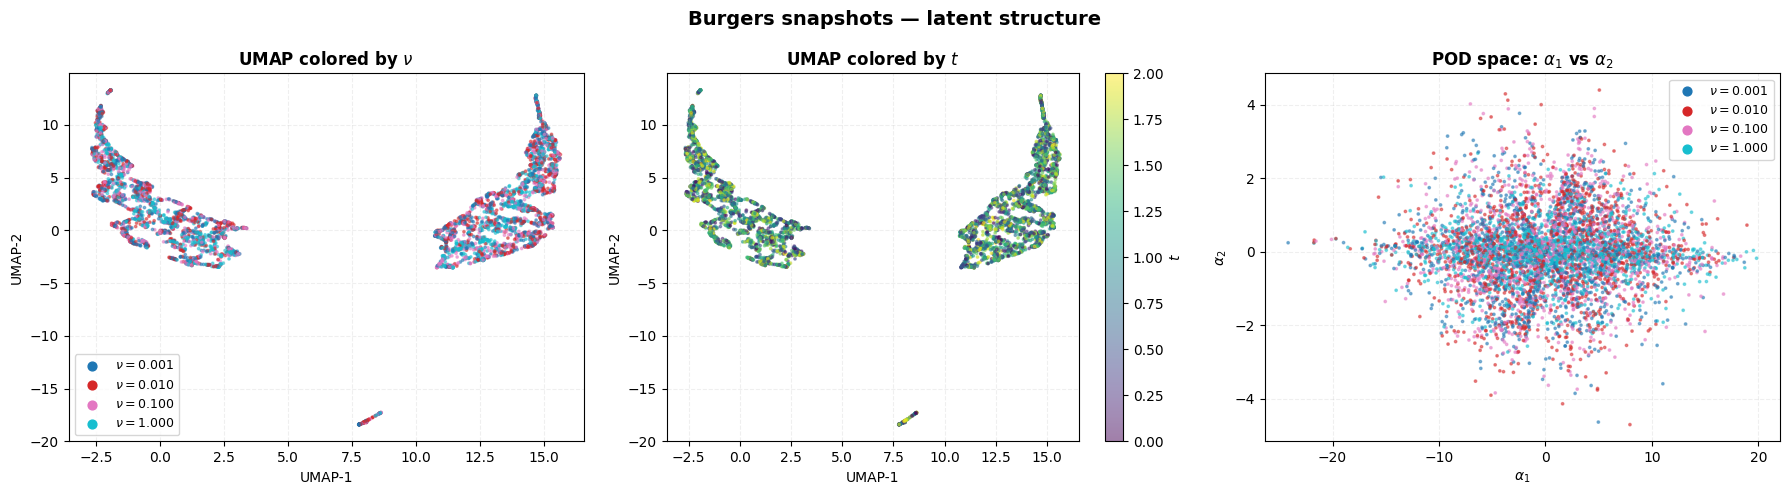

In [10]:
N_viz = 5632
idx = np.random.choice(len(s), N_viz, replace=False)

s_viz     = s[idx].cpu().numpy()
kappa_viz = kappa[idx, 0].cpu().numpy()
t_viz     = t[idx].cpu().numpy()
alpha_viz = trainer.alpha[idx].cpu().numpy() 

# UMAP on POD 
embedding = UMAP(n_neighbors=30, min_dist=0.0).fit_transform(alpha_viz)

nu_unique = np.unique(kappa_viz)
colors    = plt.cm.tab10(np.linspace(0, 0.9, len(nu_unique)))
nu_to_col = {nu: c for nu, c in zip(nu_unique, colors)}
point_colors = np.array([nu_to_col[nu] for nu in kappa_viz])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# UMAP by visc
axes[0].scatter(embedding[:, 0], embedding[:, 1], c=point_colors, s=3, alpha=0.5)
axes[0].set_title(r"UMAP colored by $\nu$", fontweight="bold")
handles = [plt.scatter([], [], color=c, s=40,label=rf"$\nu={nu:.3f}$")
           for nu, c in zip(nu_unique, colors)]
axes[0].legend(handles=handles, fontsize=9)

# UMAP by time
sc = axes[1].scatter(embedding[:, 0], embedding[:, 1], c=t_viz, cmap="viridis", s=3, alpha=0.5)
axes[1].set_title(r"UMAP colored by $t$", fontweight="bold")
plt.colorbar(sc, ax=axes[1], label=r"$t$")

# POD coefficients alpha_1 vs alpha_2
axes[2].scatter(alpha_viz[:, 0], alpha_viz[:, 1], c=point_colors, s=3, alpha=0.5)
axes[2].set_title(r"POD space: $\alpha_1$ vs $\alpha_2$", fontweight="bold")
axes[2].set_xlabel(r"$\alpha_1$"); axes[2].set_ylabel(r"$\alpha_2$")
handles2 = [plt.scatter([], [], color=c, s=40, label=rf"$\nu={nu:.3f}$")
            for nu, c in zip(nu_unique, colors)]
axes[2].legend(handles=handles2, fontsize=9)

for ax in axes[:2]:
    ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")

for ax in axes:
    ax.grid(True, ls="--", alpha=0.2)

plt.suptitle("Burgers snapshots — latent structure", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

Adding initialization results:

In [11]:
reducer = UMAP(n_neighbors=30, min_dist=0.0, random_state=39)
embedding = reducer.fit_transform(alpha_viz)

# centers to UMAP
mu_np    = trainer.mu.cpu().numpy()
mu_umap  = reducer.transform(mu_np) 
regime_colors = plt.cm.Set1(np.linspace(0, 0.8, cfg.M))
hard_labels   = trainer.gamma[idx].argmax(dim=1).cpu().numpy()

/Users/rknza/research/m1p/project/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


visualization:

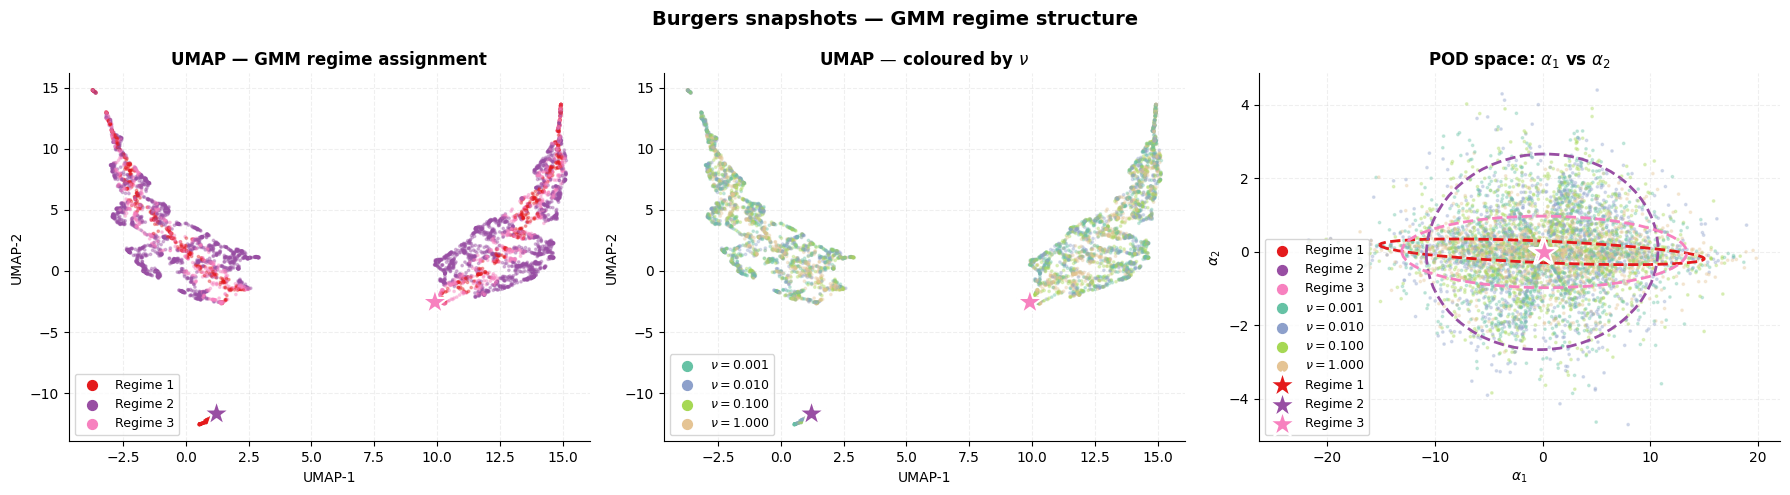

In [12]:
nu_unique  = np.unique(kappa_viz)
nu_palette = plt.cm.Set2(np.linspace(0, 0.8, len(nu_unique)))
nu_to_col  = {nu: c for nu, c in zip(nu_unique, nu_palette)}
point_colors = np.array([nu_to_col[float(nu)] for nu in kappa_viz])

star_kw = dict(s=400, marker="*", zorder=10,
               edgecolors="white", linewidths=1.5)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 0: UMAP by regime
axes[0].scatter(embedding[:, 0], embedding[:, 1],
                c=regime_colors[hard_labels], s=3, alpha=0.35, rasterized=True)
axes[0].scatter(mu_umap[:, 0], mu_umap[:, 1],
                c=regime_colors, **star_kw)
axes[0].set_title("UMAP — GMM regime assignment", fontweight="bold")
handles = [plt.scatter([], [], color=regime_colors[m], s=50, label=f"Regime {m+1}")
           for m in range(cfg.M)]
axes[0].legend(handles=handles, fontsize=9)

# Panel 1: UMAP by nu
axes[1].scatter(embedding[:, 0], embedding[:, 1],
                c=point_colors, s=3, alpha=0.3, rasterized=True)
axes[1].scatter(mu_umap[:, 0], mu_umap[:, 1],
                c=regime_colors, **star_kw)
axes[1].set_title(r"UMAP — coloured by $\nu$", fontweight="bold")
handles = [plt.scatter([], [], color=nu_to_col[nu], s=50,
                       label=rf"$\nu = {nu:.3f}$") for nu in nu_unique]
axes[1].legend(handles=handles, fontsize=9)

# Panel 2: POD space alpha_1 vs alpha_2
axes[2].scatter(alpha_viz[:, 0], alpha_viz[:, 1],
                c=point_colors, s=3, alpha=0.3, rasterized=True)
for m in range(cfg.M):
    cov2d  = trainer.Sigma[m, :2, :2].cpu().numpy()
    mean2d = mu_np[m, :2]
    draw_cov_ellipse(axes[2], mean2d, cov2d, color=regime_colors[m], linestyle="--")
    axes[2].scatter(*mean2d, color=regime_colors[m], **star_kw,
                    label=f"Regime {m+1}")
axes[2].set_title(r"POD space: $\alpha_1$ vs $\alpha_2$", fontweight="bold")
axes[2].set_xlabel(r"$\alpha_1$"); axes[2].set_ylabel(r"$\alpha_2$")
axes[2].legend(fontsize=9)

for ax in axes[:2]:
    ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
for ax in axes:
    ax.grid(True, ls="--", alpha=0.2)
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Burgers snapshots — GMM regime structure",
             fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()


- **t-SNE**:

In [13]:
alpha_with_mu = np.vstack([alpha_viz, mu_np])

tsne = TSNE(n_components=2, perplexity=50, random_state=42, n_jobs=-1)
emb_all = tsne.fit_transform(alpha_with_mu)

tsne_emb = emb_all[:-cfg.M]
mu_tsne = emb_all[-cfg.M:]

Python(33418) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


visualization:

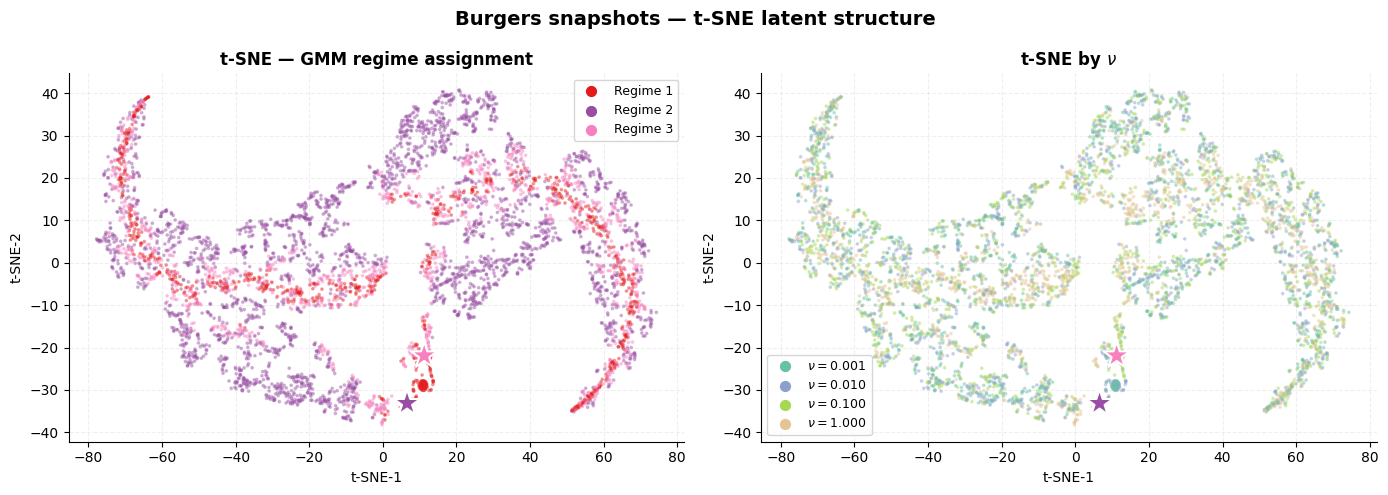

In [14]:
N_tsne   = 5000
idx_tsne = np.random.choice(len(alpha_viz), N_tsne, replace=False)

alpha_tsne     = alpha_viz[idx_tsne]
kappa_tsne     = kappa_viz[idx_tsne]
hard_tsne      = trainer.gamma[idx][idx_tsne].argmax(dim=1).cpu().numpy()
point_col_tsne = np.array([nu_to_col[float(nu)] for nu in kappa_tsne])

alpha_with_mu = np.vstack([alpha_tsne, mu_np])
emb_all       = TSNE(n_components=2, perplexity=50, random_state=42, n_jobs=-1).fit_transform(alpha_with_mu)
tsne_emb      = emb_all[:-cfg.M]
mu_tsne       = emb_all[-cfg.M:]

star_kw = dict(s=400, marker="*", zorder=10, edgecolors="white", linewidths=1.5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(tsne_emb[:, 0], tsne_emb[:, 1],
                c=regime_colors[hard_tsne], s=3, alpha=0.35, rasterized=True)
axes[0].scatter(mu_tsne[:, 0], mu_tsne[:, 1], c=regime_colors, **star_kw)
axes[0].set_title("t-SNE — GMM regime assignment", fontweight="bold")
handles = [plt.scatter([], [], color=regime_colors[m], s=50, label=f"Regime {m+1}")
           for m in range(cfg.M)]
axes[0].legend(handles=handles, fontsize=9)

axes[1].scatter(tsne_emb[:, 0], tsne_emb[:, 1],
                c=point_col_tsne, s=3, alpha=0.35, rasterized=True)
axes[1].scatter(mu_tsne[:, 0], mu_tsne[:, 1], c=regime_colors, **star_kw)
axes[1].set_title(r"t-SNE by $\nu$", fontweight="bold")
handles = [plt.scatter([], [], color=nu_to_col[nu], s=50,
                       label=rf"$\nu = {nu:.3f}$") for nu in nu_unique]
axes[1].legend(handles=handles, fontsize=9)

for ax in axes:
    ax.set_xlabel("t-SNE-1"); ax.set_ylabel("t-SNE-2")
    ax.grid(True, ls="--", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Burgers snapshots — t-SNE latent structure",
             fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()


#### **Fourier Neural POD**

In [15]:
cfg = TEMPOConfig(
    M=3,
    basis_config=FourierNeuralPODConfig(max_modes=1, n_epochs_mode=5, n_epochs_mean=5),
    basis_factory=fourier_pod_factory,
    P_global = 3
)
trainer_f = TEMPOTrainer(cfg)
trainer_f._initialize(s, x, t, kappa)

POD | N=5632000, Ny=101 | max_modes=3, tol=1.0
  P=3 modes (100.00% variance threshold, needed 101)
  mode  1: sigma=6.0450e+00  cumvar=92.59%  res_mse=2.8989e-02
  mode  2: sigma=1.0690e+00  cumvar=95.49%  res_mse=1.7667e-02
  mode  3: sigma=7.2902e-01  cumvar=96.84%  res_mse=1.2387e-02
  done: final res_mse=1.2387e-02
Fourier NeuralPOD | N=5632000, Ny=101 | max_modes=1


mean:   0%|          | 0/5 [00:00<?, ?it/s]

mode 1:   0%|          | 0/5 [00:00<?, ?it/s]

  mode 1: weighted_res=5.6786e-01
  done: 1 modes

Fourier NeuralPOD | N=5632000, Ny=101 | max_modes=1


mean:   0%|          | 0/5 [00:00<?, ?it/s]

mode 1:   0%|          | 0/5 [00:00<?, ?it/s]

  mode 1: weighted_res=3.3440e-01
  done: 1 modes

Fourier NeuralPOD | N=5632000, Ny=101 | max_modes=1


mean:   0%|          | 0/5 [00:00<?, ?it/s]

mode 1:   0%|          | 0/5 [00:00<?, ?it/s]

  mode 1: weighted_res=4.3898e-01
  done: 1 modes

  calibrated sigma2 = 1.9988e-01


In [16]:
N_viz = 10000
idx = np.random.choice(len(s), N_viz, replace=False)

s_viz     = s[idx].cpu().numpy()
kappa_viz = kappa[idx, 0].cpu().numpy()
t_viz     = t[idx].cpu().numpy()
alpha_viz = trainer_f.alpha[idx].cpu().numpy() 

In [17]:
reducer = UMAP(n_neighbors=30, min_dist=0.0)
embedding = reducer.fit_transform(alpha_viz)

# centers to UMAP
mu_np    = trainer_f.mu.cpu().numpy()
mu_umap  = reducer.transform(mu_np) 
regime_colors = plt.cm.Set1(np.linspace(0, 0.8, cfg.M))
hard_labels   = trainer_f.gamma[idx].argmax(dim=1).cpu().numpy()

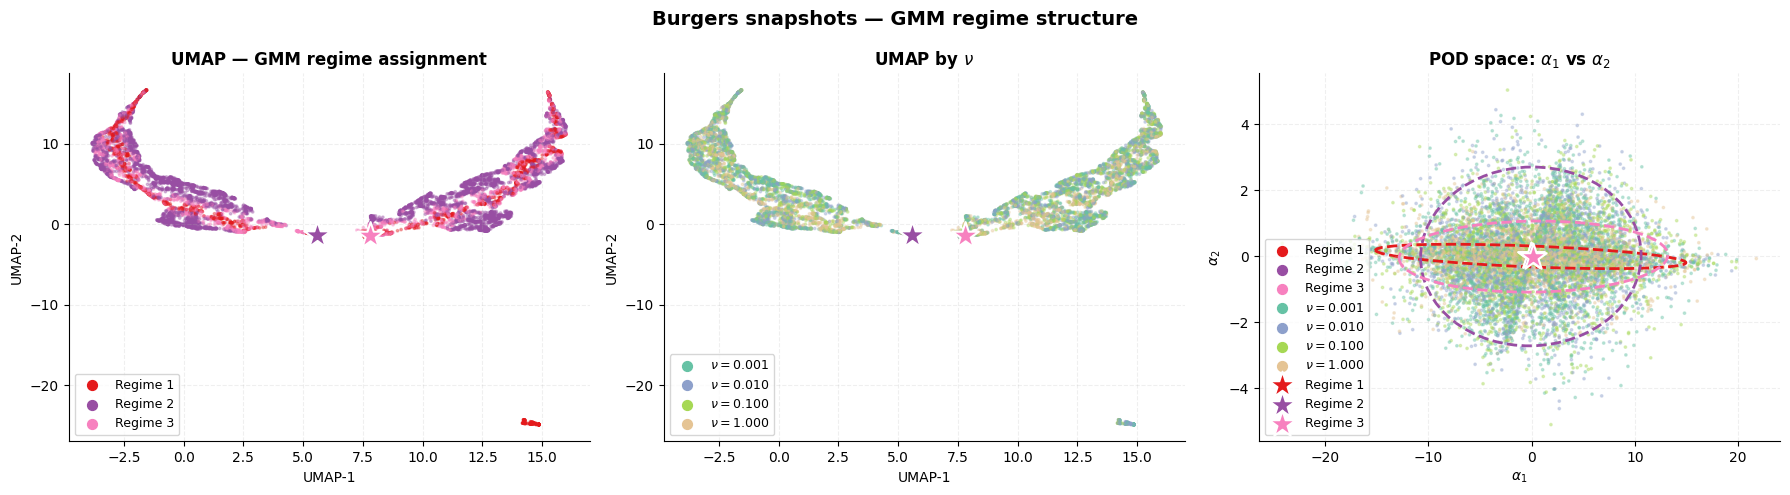

In [18]:
nu_unique    = np.unique(kappa_viz)
nu_palette   = plt.cm.Set2(np.linspace(0, 0.8, len(nu_unique)))
nu_to_col    = {nu: c for nu, c in zip(nu_unique, nu_palette)}
point_colors = np.array([nu_to_col[float(nu)] for nu in kappa_viz])

star_kw = dict(s=400, marker="*", zorder=10, edgecolors="white", linewidths=1.5)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 0: UMAP by regime
axes[0].scatter(embedding[:, 0], embedding[:, 1],
                c=regime_colors[hard_labels], s=3, alpha=0.35, rasterized=True)
axes[0].scatter(mu_umap[:, 0], mu_umap[:, 1], c=regime_colors, **star_kw)
axes[0].set_title("UMAP — GMM regime assignment", fontweight="bold")
handles = [plt.scatter([], [], color=regime_colors[m], s=50, label=f"Regime {m+1}")
           for m in range(cfg.M)]
axes[0].legend(handles=handles, fontsize=9)

# Panel 1: UMAP by nu
axes[1].scatter(embedding[:, 0], embedding[:, 1],
                c=point_colors, s=3, alpha=0.35, rasterized=True)
axes[1].scatter(mu_umap[:, 0], mu_umap[:, 1], c=regime_colors, **star_kw)
axes[1].set_title(r"UMAP by $\nu$", fontweight="bold")
handles = [plt.scatter([], [], color=nu_to_col[nu], s=50,
                       label=rf"$\nu = {nu:.3f}$") for nu in nu_unique]
axes[1].legend(handles=handles, fontsize=9)

# Panel 2: POD space alpha_1 vs alpha_2
axes[2].scatter(alpha_viz[:, 0], alpha_viz[:, 1],
                c=point_colors, s=3, alpha=0.35, rasterized=True)
for m in range(cfg.M):
    cov2d  = trainer_f.Sigma[m, :2, :2].cpu().numpy()
    mean2d = mu_np[m, :2]
    draw_cov_ellipse(axes[2], mean2d, cov2d, color=regime_colors[m], linestyle="--")
    axes[2].scatter(*mean2d, color=regime_colors[m], **star_kw,
                    label=f"Regime {m+1}")
axes[2].set_title(r"POD space: $\alpha_1$ vs $\alpha_2$", fontweight="bold")
axes[2].set_xlabel(r"$\alpha_1$"); axes[2].set_ylabel(r"$\alpha_2$")
axes[2].legend(fontsize=9)

for ax in axes[:2]:
    ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
for ax in axes:
    ax.grid(True, ls="--", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Burgers snapshots — GMM regime structure",
             fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()